In [1]:
import qiskit
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeFez

from qiskit.visualization import plot_histogram



# Define Main Paths, Constants

In [2]:
# The nodes of the network
node_names = [0, 1, 2, 3, 4, 5]

network_nodes = {}
node_qubit_mappings = {}
for node in node_names:
    network_nodes[node] = QuantumRegister(9, name=f'q_{node}')
        # 'classical': ClassicalRegister(4, name=f'c_{node}')


print(network_nodes)


{0: QuantumRegister(9, 'q_0'), 1: QuantumRegister(9, 'q_1'), 2: QuantumRegister(9, 'q_2'), 3: QuantumRegister(9, 'q_3'), 4: QuantumRegister(9, 'q_4'), 5: QuantumRegister(9, 'q_5')}


In [3]:
network_channel_noise = NoiseModel()
# # depolarizing error on single qubit gates
# dep_error_1q = depolarizing_error(0.001, 1)
# # depolarizing error on two qubit gates
# dep_error_2q = depolarizing_error(0.01, 2)
# # thermal relaxation error on single qubit gates
# therm_error_1q = thermal_relaxation_error(50, 100, 0.1)
# # thermal relaxation error on two qubit gates
# therm_error_2q = thermal_relaxation_error(50, 100, 0.2).tensor(thermal_relaxation_error(50, 100, 0.2))  
# # add errors to noise model
# network_channel_noise.add_all_qubit_quantum_error(dep_error_1q.compose(therm_error_1q), ['u1', 'u2', 'u3'])
# network_channel_noise.add_all_qubit_quantum_error(dep_error_2q.compose(therm_error_2q), ['swap']) 
network_channel_noise = NoiseModel.from_backend(FakeFez())
print(network_channel_noise)

NoiseModel:
  Basis gates: ['cz', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
  Instructions with noise: ['reset', 'sx', 'x', 'id', 'cz', 'measure']
  Qubits with noise: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155]
  Specific qubit errors: [('reset', (0,)), ('reset', (1,)), ('reset', (2,)), ('reset', (3,)), ('reset', (4,)), ('

In [4]:
network_registers = [x[1] for x in network_nodes.items()]
print(network_registers)

[QuantumRegister(9, 'q_0'), QuantumRegister(9, 'q_1'), QuantumRegister(9, 'q_2'), QuantumRegister(9, 'q_3'), QuantumRegister(9, 'q_4'), QuantumRegister(9, 'q_5')]


In [5]:
network_circuit = QuantumCircuit(*network_registers)

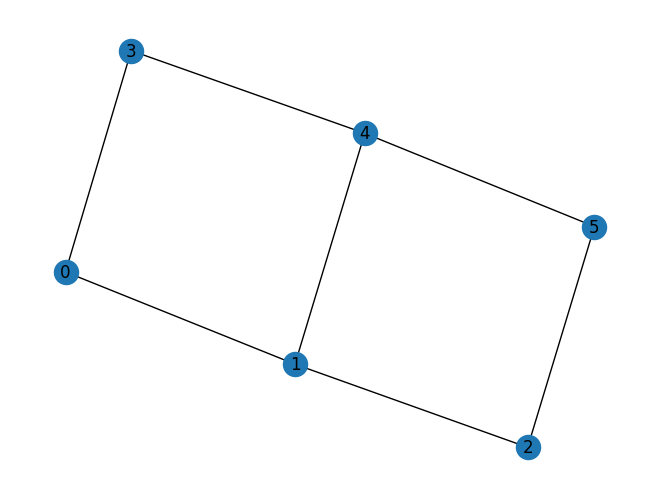

In [6]:
import networkx as nx

network_graph = nx.Graph()
network_graph.add_nodes_from(node_names)
network_graph.add_edges_from([(0, 1), (1, 2), (0, 3), (1, 4), (2, 5), (3, 4), (4, 5)])
nx.draw(network_graph, with_labels=True)

swaps_per_edge = {
    (0, 1): 3,
    (1, 2): 3,
    (0, 3): 2,
    (1, 4): 2,
    (2, 5): 2,
    (3, 4): 3,
    (4, 5): 3
}

# Encoding Circuit

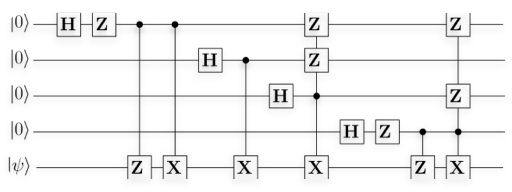

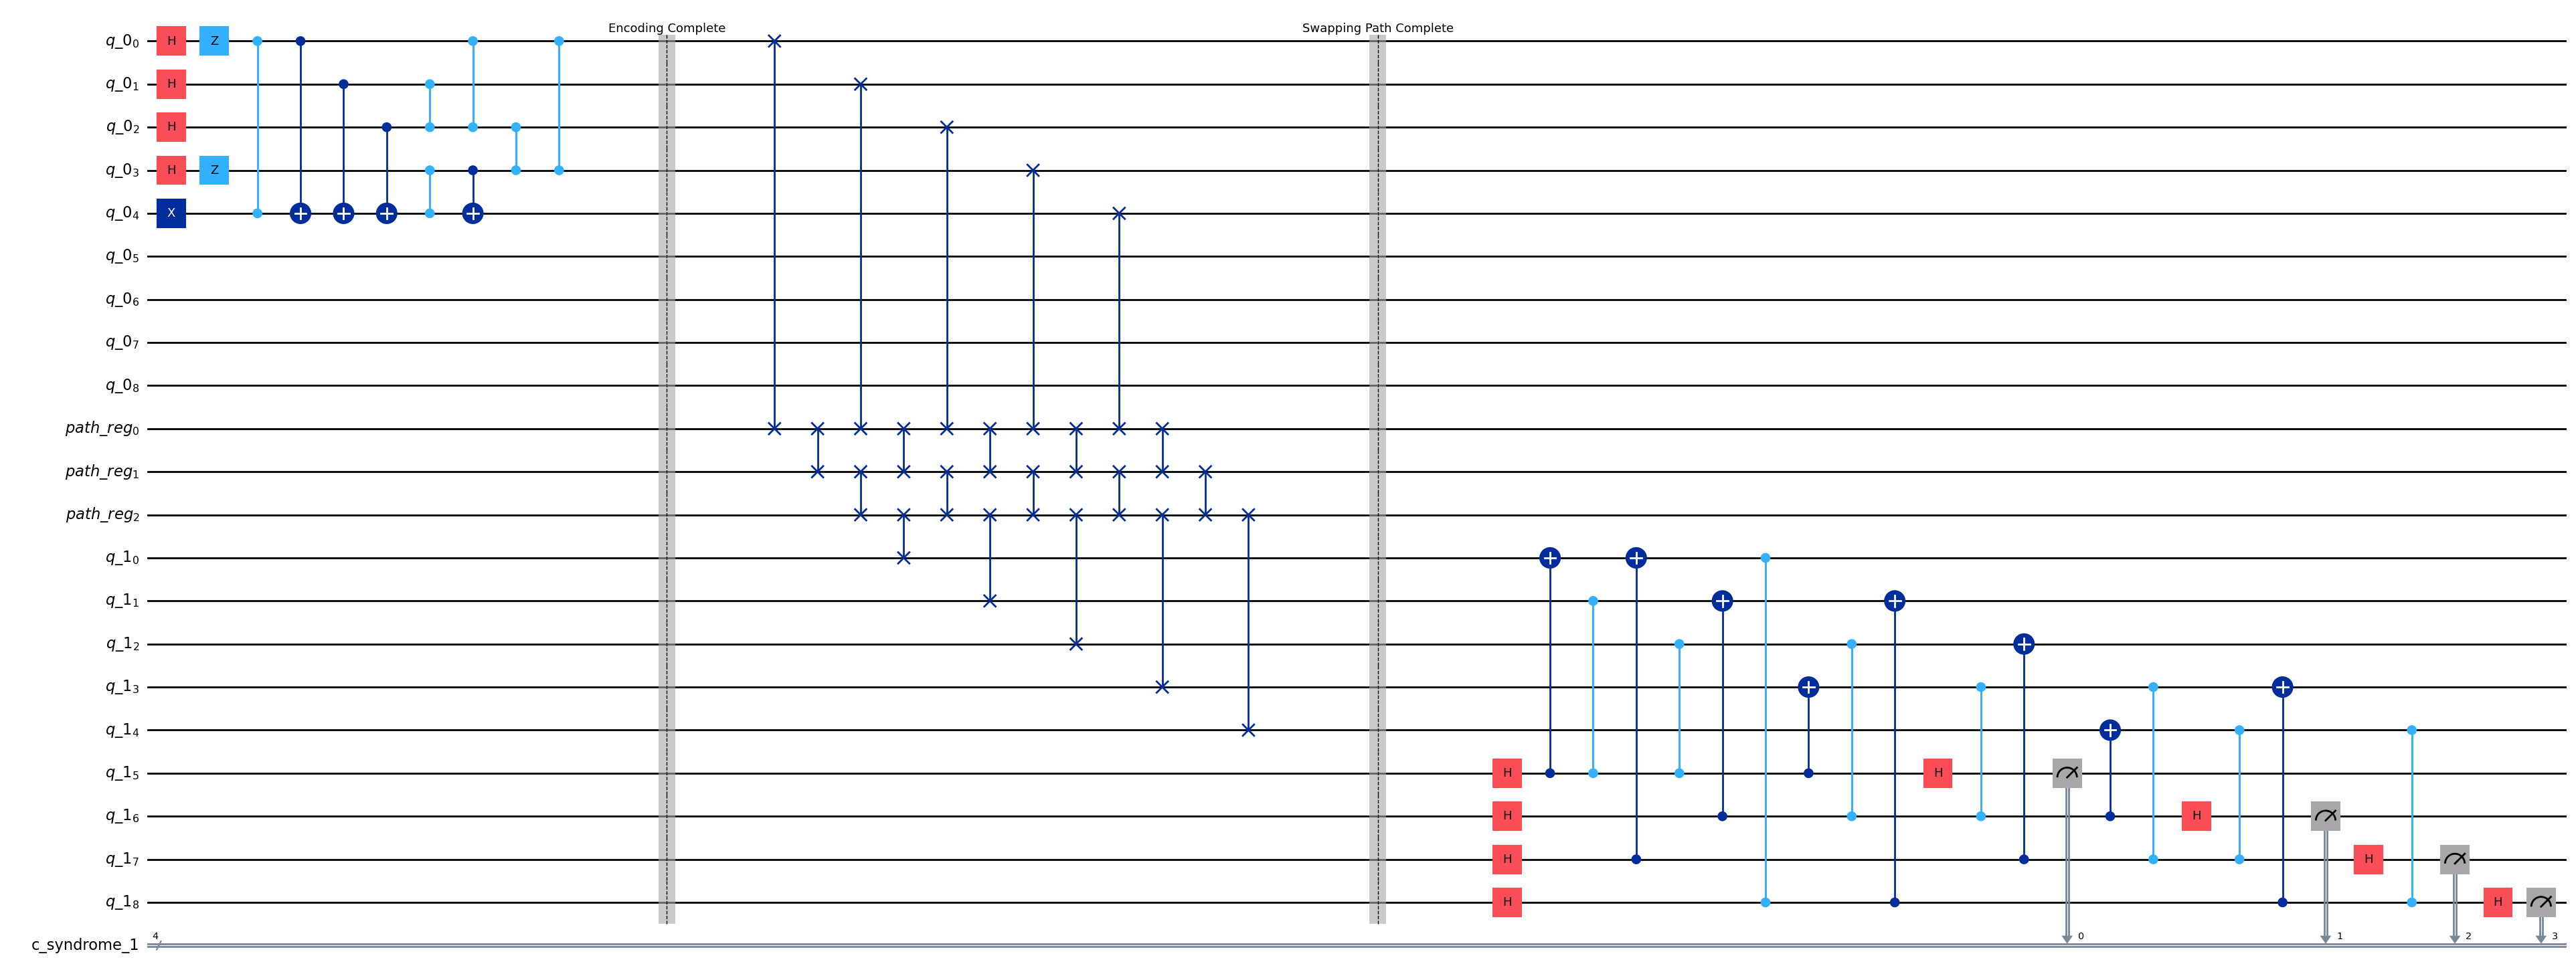

In [7]:

def build_swapping_circuit_syndrome(source, sink, initial_state='0'):
    # qc = QuantumCircuit(*network_registers)
    source_reg = network_nodes[source]
    sink_reg = network_nodes[sink]
    path_reg = QuantumRegister(swaps_per_edge[(source, sink)], name='path_reg')
    qc = QuantumCircuit(source_reg, path_reg, sink_reg)
    # sink_syndrome_bits = network_nodes[sink]['classical']
    sink_syndrome_bits = ClassicalRegister(4, name=f'c_syndrome_{sink}')
    qc.add_register(sink_syndrome_bits)
    
    # Prepare initial state at source
    # Keep qubit 4 as data qubit, 0-3 as encoding ancillas
    if initial_state == '1':
        qc.x(source_reg[4])

    # Encoding using 5-qubit code
    qc.h(source_reg[0])
    qc.z(source_reg[0])
    qc.cz(source_reg[0], source_reg[4])
    qc.cx(source_reg[0], source_reg[4])

    qc.h(source_reg[1])
    qc.cx(source_reg[1], source_reg[4])

    qc.h(source_reg[2])
    qc.cx(source_reg[2], source_reg[4])
    qc.cz(source_reg[2], source_reg[1])
    qc.cz(source_reg[2], source_reg[0])

    qc.h(source_reg[3])
    qc.z(source_reg[3])
    qc.cz(source_reg[3], source_reg[4])
    qc.cx(source_reg[3], source_reg[4])
    qc.cz(source_reg[3], source_reg[2])
    qc.cz(source_reg[3], source_reg[0])
    
    
    qc.barrier(label='Encoding Complete')
    
    # Swap from source to sink
    for i in range(5):
        qc.swap(source_reg[i], path_reg[0])
        for j in range(swaps_per_edge[(source, sink)] - 1):
            qc.swap(path_reg[j], path_reg[j + 1])
        qc.swap(path_reg[swaps_per_edge[(source, sink)] - 1], sink_reg[i])
    
    qc.barrier(label='Swapping Path Complete')

    # Syndrome measurement at sink
    stabilizers = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]

    for idx, stabilizer in enumerate(stabilizers):
        a_i = idx + 5
        qc.h(sink_reg[a_i])
        
        for qubit_idx, pauli in enumerate(stabilizer):
            if pauli == 'X':
                qc.cx(sink_reg[a_i], sink_reg[qubit_idx])
            elif pauli == 'Z':
                qc.cz(sink_reg[a_i], sink_reg[qubit_idx])
        
        qc.h(sink_reg[a_i])
        qc.measure(sink_reg[a_i], sink_syndrome_bits[idx])

    return qc


a_to_b_circuit = build_swapping_circuit_syndrome(0,1, initial_state='1')
a_to_b_circuit.draw('mpl', fold=-1)

In [8]:
simulator = AerSimulator(noise_model=None)
compiled_circuit = transpile(a_to_b_circuit, simulator)
result = simulator.run(compiled_circuit, shots=4096).result()
counts = dict(sorted(result.get_counts().items(), key=lambda x: x[0]))
print(counts)

{'0000': 4096}


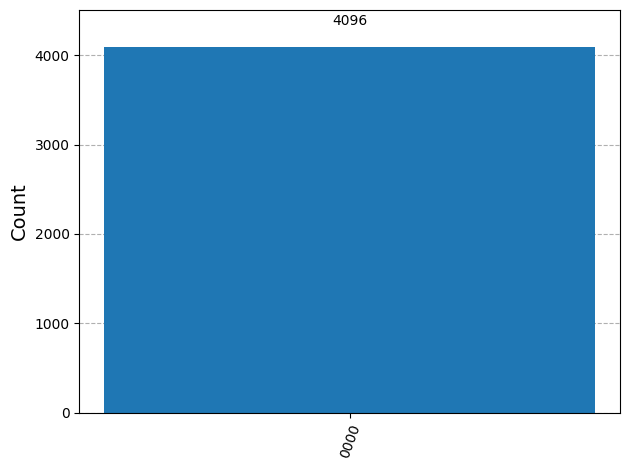

In [9]:
plot_histogram(counts)

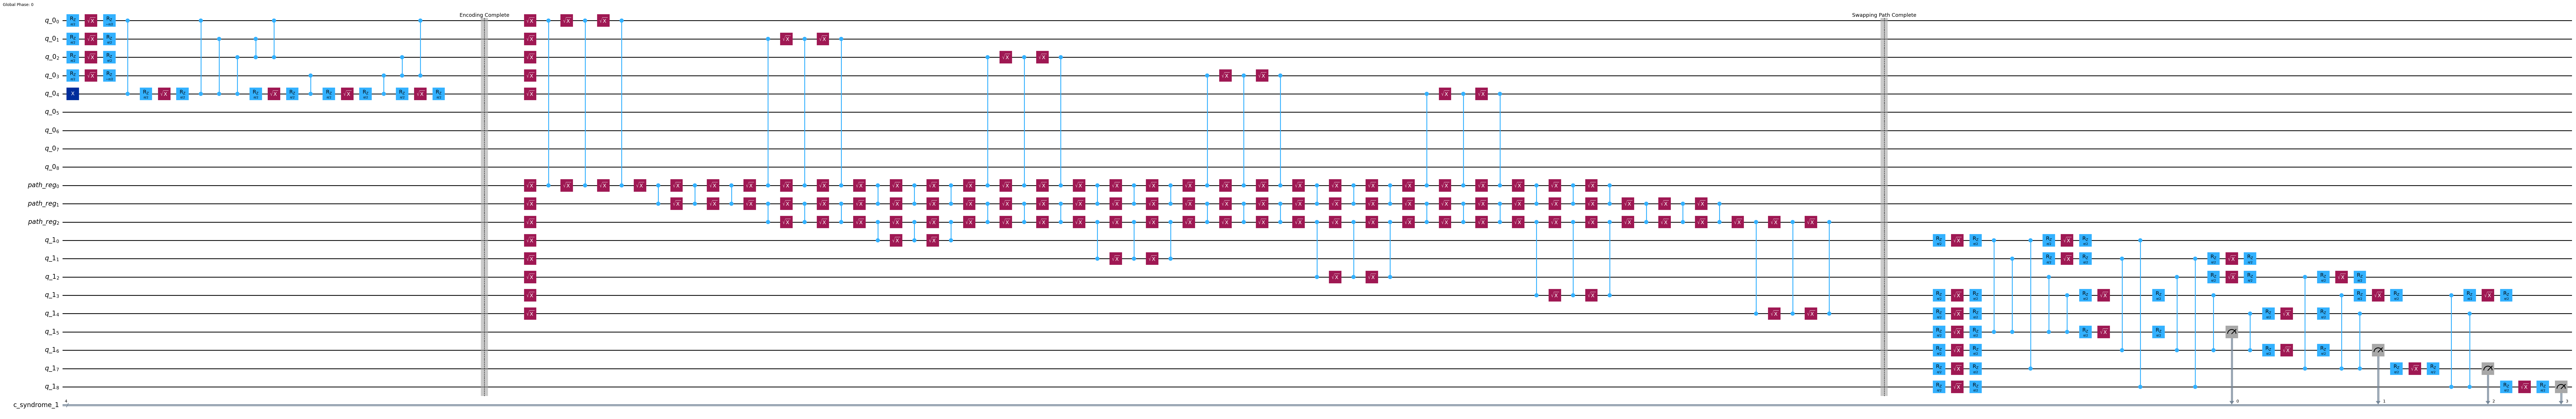

In [10]:
noisy_simulator = AerSimulator(noise_model=network_channel_noise)
noisy_compiled_circuit = transpile(a_to_b_circuit, noisy_simulator, optimization_level=1)
noisy_compiled_circuit.draw('mpl', fold=-1)

In [11]:

noisy_result = noisy_simulator.run(noisy_compiled_circuit, shots=4096).result()
noisy_counts = dict(sorted(noisy_result.get_counts().items(), key=lambda x: x[0]))
print(noisy_counts)

{'0000': 3394, '0001': 52, '0010': 61, '0011': 24, '0100': 73, '0101': 58, '0110': 28, '0111': 41, '1000': 71, '1001': 35, '1010': 44, '1011': 41, '1100': 39, '1101': 61, '1110': 41, '1111': 33}


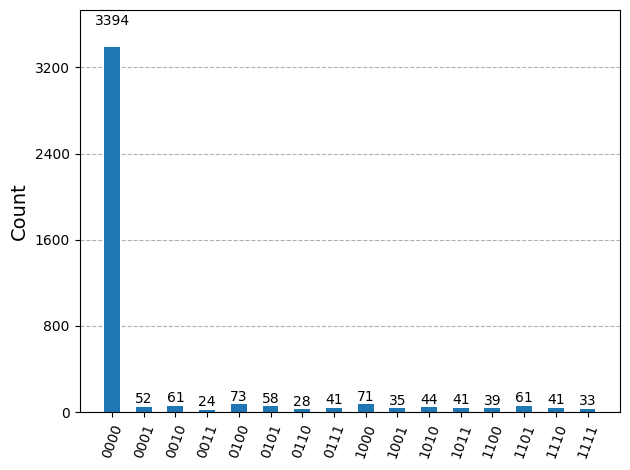

In [12]:
plot_histogram(noisy_counts)

In [13]:
class TimeAwareMeasurement:
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='513'):
        """
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A 16-dimensional numpy array of syndrome counts.
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with 'max', 'std', 'count'.
        :param code_type: String indicating the code type, e.g., '313_X', '313_Z', '513'.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type  # Default, will be updated per sample


# 513 Syndrome Data

In [14]:
import numpy as np

EDGE_SYNDROME_DATA = {}
TIME_AWARE_MEASUREMENTS = []
NOISY_AER_SIM = AerSimulator(noise_model=network_channel_noise)
NUM_SHOTS = 4096
for edge in network_graph.edges():
    print(edge)
    circuit = build_swapping_circuit_syndrome(edge[0], edge[1], initial_state='0')
    transpiled_circuit = transpile(circuit, NOISY_AER_SIM, optimization_level=1)
    noisy_result = NOISY_AER_SIM.run(transpiled_circuit, shots=NUM_SHOTS).result()
    noisy_counts = dict(sorted(noisy_result.get_counts().items(), key=lambda x: x[0]))
    
    meta_list = getattr(noisy_result, "metadata", None)
    if meta_list is not None and len(meta_list) > 0:
        timing = meta_list.get('time_taken_execute', 1e-3)
    else:
        timing = 1e-3  # default small value
    
    per_shot_timing = timing / NUM_SHOTS  # average time per shot
    print(noisy_counts)    
    print(timing, per_shot_timing)
    measurement_data = TimeAwareMeasurement(
        path_edges=[edge],
        histogram=np.array(list(noisy_counts.values())),
        duration=0.0, 
        latency_stats={},
        code_type='513'
    )
    EDGE_SYNDROME_DATA[edge] = {edge: noisy_counts}
    TIME_AWARE_MEASUREMENTS.append(measurement_data)


(0, 1)
{'0000': 3373, '0001': 51, '0010': 57, '0011': 30, '0100': 66, '0101': 59, '0110': 21, '0111': 41, '1000': 62, '1001': 48, '1010': 45, '1011': 47, '1100': 51, '1101': 59, '1110': 45, '1111': 41}
15.144900667 0.003697485514404297
(0, 3)
{'0000': 3516, '0001': 77, '0010': 49, '0011': 19, '0100': 45, '0101': 49, '0110': 22, '0111': 25, '1000': 88, '1001': 29, '1010': 29, '1011': 38, '1100': 22, '1101': 32, '1110': 29, '1111': 27}
6.776081875 0.0016543168640136719
(1, 2)
{'0000': 3313, '0001': 53, '0010': 59, '0011': 34, '0100': 83, '0101': 70, '0110': 31, '0111': 51, '1000': 66, '1001': 40, '1010': 30, '1011': 56, '1100': 58, '1101': 54, '1110': 59, '1111': 39}
15.548215834 0.0037959511313476564
(1, 4)
{'0000': 3502, '0001': 74, '0010': 48, '0011': 13, '0100': 61, '0101': 55, '0110': 19, '0111': 28, '1000': 79, '1001': 27, '1010': 30, '1011': 39, '1100': 22, '1101': 45, '1110': 39, '1111': 15}
6.484428167 0.0015831123454589844
(2, 5)
{'0000': 3475, '0001': 60, '0010': 55, '0011': 1

# Ground Truth Data

In [15]:

def build_swapping_circuit_ground_truth(source, sink, initial_state='0', measurement_basis='Z'):
    # qc = QuantumCircuit(*network_registers)
    source_register = network_nodes[source]
    sink_register = network_nodes[sink]
    source_qubit = source_register[4]
    sink_qubit = sink_register[4]
    path_reg = QuantumRegister(swaps_per_edge[(source, sink)], name='path_reg')
    qc = QuantumCircuit(source_register, path_reg, sink_register)
    
    if initial_state == '1':
        qc.x(source_qubit)

    # Rotate to measurement basis if needed
    if measurement_basis == 'X':
        qc.h(source_qubit)
    elif measurement_basis == 'Y':
        qc.h(source_qubit)        
        qc.s(source_qubit)


    # Swapping Path from source to sink
    qc.swap(source_qubit, path_reg[0])
    for j in range(swaps_per_edge[(source, sink)] - 1):
        qc.swap(path_reg[j], path_reg[j + 1])
    qc.swap(path_reg[swaps_per_edge[(source, sink)] - 1], sink_qubit)
    

    creg = ClassicalRegister(1, name='c_data')
    qc.add_register(creg)

    # Rotating back to 'Z' with accumulated errors
    if measurement_basis == 'X':
        qc.h(sink_qubit)
    elif measurement_basis == 'Y':
        qc.sdg(sink_qubit)
        qc.h(sink_qubit)    

    qc.measure(sink_qubit, creg[0])  # Measure the data qubit directly

    return qc



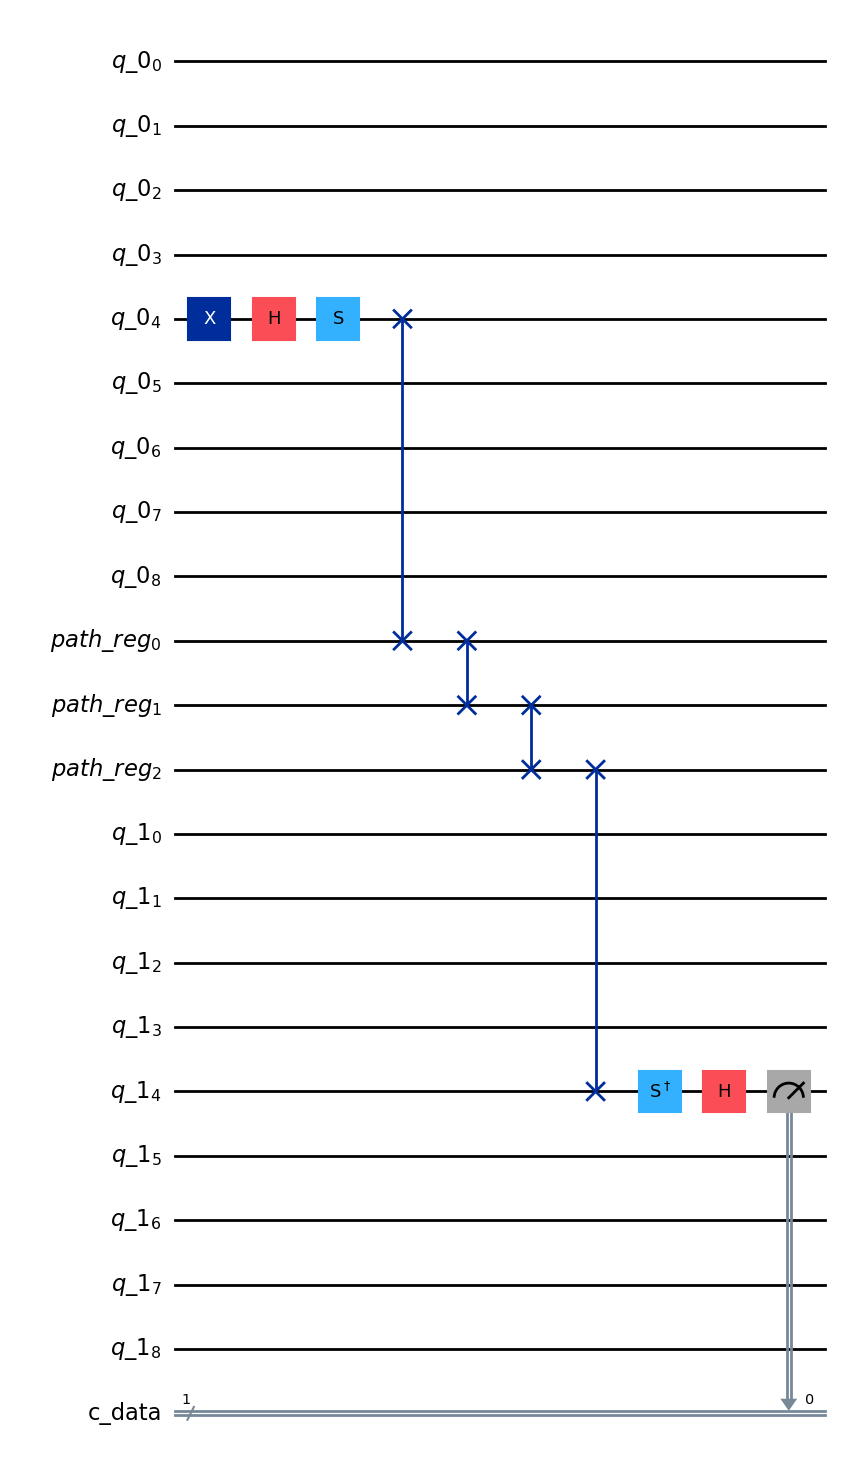

In [16]:
a_to_b_circuit = build_swapping_circuit_ground_truth(0,1, measurement_basis='Y', initial_state='1')
a_to_b_circuit.draw('mpl', fold=-1)

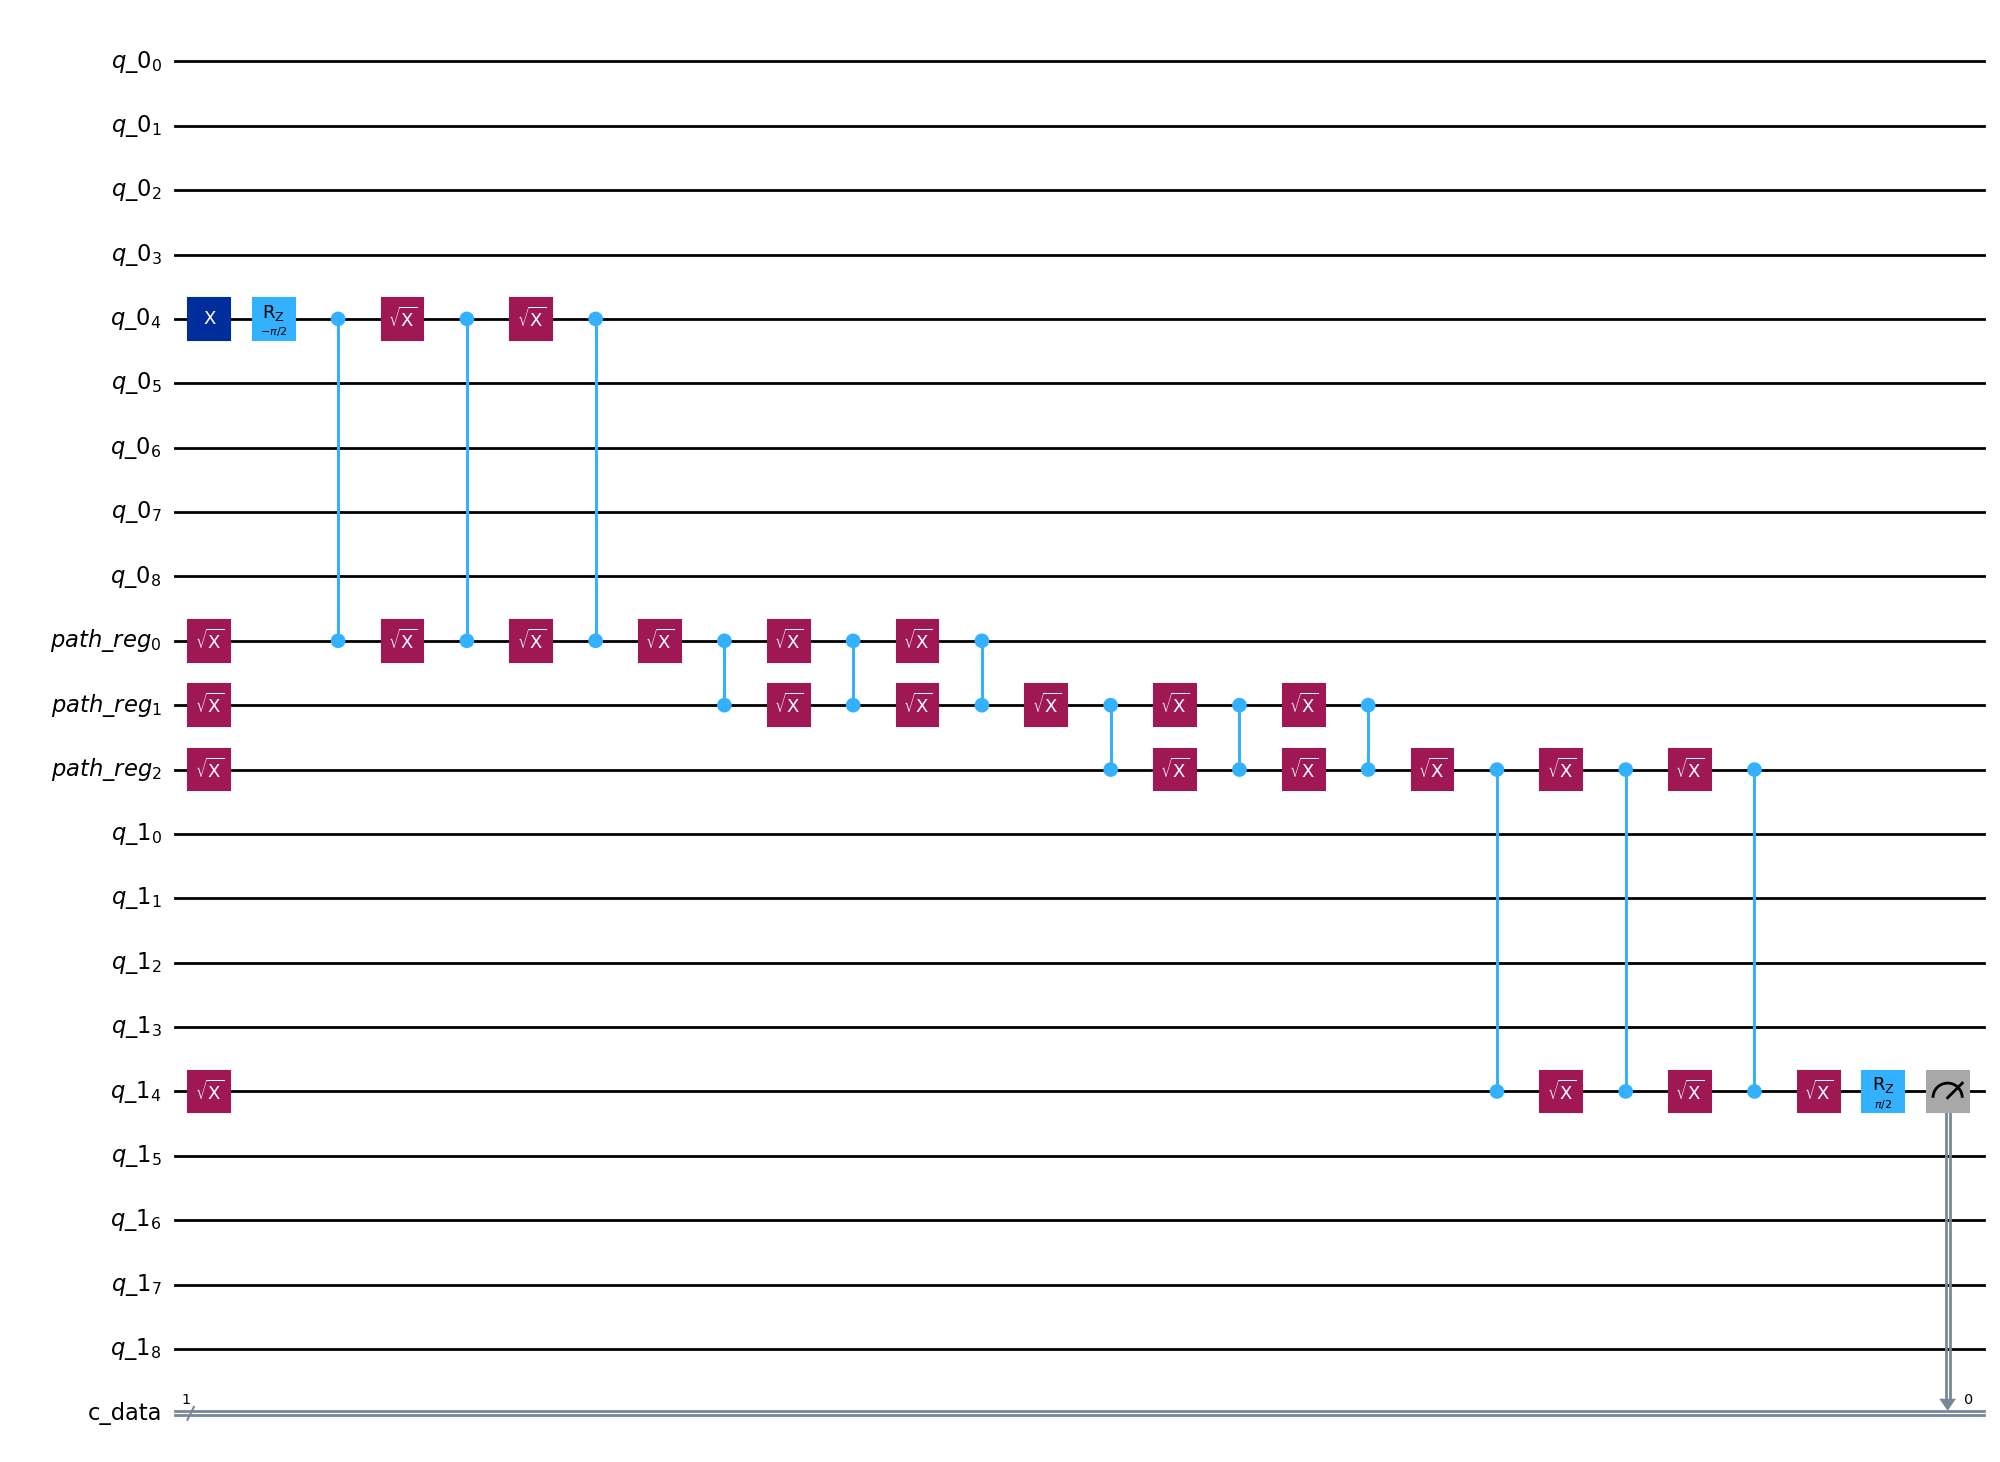

In [17]:
# noisy_simulator = AerSimulator(noise_model=network_channel_noise)
noisy_compiled_circuit = transpile(a_to_b_circuit, noisy_simulator, optimization_level=1)
noisy_compiled_circuit.draw('mpl', fold=-1)

In [18]:
noisy_result = noisy_simulator.run(noisy_compiled_circuit, shots=4096).result()
noisy_counts = dict(sorted(noisy_result.get_counts().items(), key=lambda x: x[0]))
print(noisy_counts)

{'0': 122, '1': 3974}


In [19]:
from typing import Dict


def calculate_exact_pauli_rates(
    z_basis_counts: Dict[str, int],
    x_basis_counts: Dict[str, int],
    y_basis_counts: Dict[str, int],
    expected_state: str = '0'
) -> Dict[str, float]:
    """
    Calculate exact X, Y, and Z error rates using full quantum state tomography.
    
    Requires three independent measurement runs in different bases to solve
    the system of equations for Pauli error probabilities.
    
    Theory:
        - Z-basis measurement detects: E_z = P(X) + P(Y)
        - X-basis measurement detects: E_x = P(Z) + P(Y)
        - Y-basis measurement detects: E_y = P(X) + P(Z)
    
    Solving this system:
        P(X) = (E_z + E_y - E_x) / 2
        P(Y) = (E_z + E_x - E_y) / 2
        P(Z) = (E_x + E_y - E_z) / 2
    
    Args:
        z_basis_counts: Measurement counts from Z-basis run (detects X and Y errors)
                       e.g., {'0': 850, '1': 50}
        x_basis_counts: Measurement counts from X-basis run (detects Z and Y errors)
                       e.g., {'0': 820, '1': 60}
        y_basis_counts: Measurement counts from Y-basis run (detects X and Z errors)
                       e.g., {'0': 800, '1': 70}
        expected_state: Expected outcome without errors ('0' or '1')
    
    Returns:
        Dictionary with exact error rates:
        {
            'PX': float,  # X error probability
            'PY': float,  # Y error probability
            'PZ': float,  # Z error probability
            'E_z': float, # Raw Z-basis error rate
            'E_x': float, # Raw X-basis error rate
            'E_y': float, # Raw Y-basis error rate
            'total_shots': dict
        }
    """
    
    def get_error_rate(counts: Dict[str, int], correct_label: str) -> float:
        """Calculate the total error rate for a measurement basis."""
        total_shots = sum(counts.values())
        if total_shots == 0:
            return 0.0
        
        correct_shots = counts.get(correct_label, 0)
        return 1.0 - (correct_shots / total_shots)
    
    # Calculate observed error rates in each basis
    E_z = get_error_rate(z_basis_counts, expected_state)  # P(X) + P(Y)
    E_x = get_error_rate(x_basis_counts, expected_state)  # P(Z) + P(Y)
    E_y = get_error_rate(y_basis_counts, expected_state)  # P(X) + P(Z)
    
    # Solve the system of linear equations
    px = 0.5 * (E_z + E_y - E_x)
    py = 0.5 * (E_z + E_x - E_y)
    pz = 0.5 * (E_x + E_y - E_z)
    
    # Clean up small negatives due to statistical noise
    return {
        'p_x': max(0.0, px),
        'p_y': max(0.0, py),
        'p_z': max(0.0, pz),
        'E_z': E_z,
        'E_x': E_x,
        'E_y': E_y,
        'total_shots': {
            'z_basis': sum(z_basis_counts.values()),
            'x_basis': sum(x_basis_counts.values()),
            'y_basis': sum(y_basis_counts.values())
        }
    }



In [20]:
GROUND_TRUTH_DATA = {}

for edge in network_graph.edges():
    print(edge)
    circuit_Z = build_swapping_circuit_ground_truth(edge[0], edge[1], measurement_basis='Z')
    circuit_X = build_swapping_circuit_ground_truth(edge[0], edge[1], measurement_basis='X')
    circuit_Y = build_swapping_circuit_ground_truth(edge[0], edge[1], measurement_basis='Y')

    transpiled_circuit_Z = transpile(circuit_Z, NOISY_AER_SIM, optimization_level=1)
    transpiled_circuit_X = transpile(circuit_X, NOISY_AER_SIM, optimization_level=1)
    transpiled_circuit_Y = transpile(circuit_Y, NOISY_AER_SIM, optimization_level=1)

    print("Running Z-basis measurement...", end=' | ')
    counts_Z = dict(sorted(NOISY_AER_SIM.run(transpiled_circuit_Z, shots=NUM_SHOTS).result().get_counts().items(), key=lambda x: x[0]))
    print("Running X-basis measurement...", end=' | ')
    counts_X = dict(sorted(NOISY_AER_SIM.run(transpiled_circuit_X, shots=NUM_SHOTS).result().get_counts().items(), key=lambda x: x[0]))
    print("Running Y-basis measurement...")
    counts_Y = dict(sorted(NOISY_AER_SIM.run(transpiled_circuit_Y, shots=NUM_SHOTS).result().get_counts().items(), key=lambda x: x[0]))

    error_rates = calculate_exact_pauli_rates(
        z_basis_counts=counts_Z,
        x_basis_counts=counts_X,
        y_basis_counts=counts_Y,
        expected_state='0'
    )

    GROUND_TRUTH_DATA[edge] = [error_rates['p_x'], error_rates['p_y'], error_rates['p_z']]
    print(f"Pauli Error calculated for edge {edge}: PX: {error_rates['p_x']}, PY: {error_rates['p_y']}, PZ: {error_rates['p_z']}")
    print(f"E_x/y/z: {error_rates['E_x']}/{error_rates['E_y']}/{error_rates['E_z']} \n")
    # print(f"Basis Measurements Counts: Z: {counts_Z}, X: {counts_X}, Y: {counts_Y}")
    # print(f"Circuit Depth: Swapping: {circuit_Z.depth()}, Total: {circuit_Z.size()}")
    # print(f"Circuit Depth: Transpiled: {transpiled_circuit_Z.depth()}, Total: {transpiled_circuit_Z.size()}")



    
    
 

(0, 1)
Running Z-basis measurement... | Running X-basis measurement... | Running Y-basis measurement...
Pauli Error calculated for edge (0, 1): PX: 0.0167236328125, PY: 0.0155029296875, PZ: 0.0125732421875
E_x/y/z: 0.028076171875/0.029296875/0.0322265625 

(0, 3)
Running Z-basis measurement... | Running X-basis measurement... | Running Y-basis measurement...
Pauli Error calculated for edge (0, 3): PX: 0.02099609375, PY: 0.022216796875, PZ: 0.02392578125
E_x/y/z: 0.046142578125/0.044921875/0.043212890625 

(1, 2)
Running Z-basis measurement... | Running X-basis measurement... | Running Y-basis measurement...
Pauli Error calculated for edge (1, 2): PX: 0.0140380859375, PY: 0.0174560546875, PZ: 0.0152587890625
E_x/y/z: 0.03271484375/0.029296875/0.031494140625 

(1, 4)
Running Z-basis measurement... | Running X-basis measurement... | Running Y-basis measurement...
Pauli Error calculated for edge (1, 4): PX: 0.01953125, PY: 0.024658203125, PZ: 0.021240234375
E_x/y/z: 0.0458984375/0.04077148

In [21]:
import os
import pickle

DATA_DIR = '../pickle_files/syndrome_data_513/'
os.makedirs(DATA_DIR, exist_ok=True)
with open(os.path.join(DATA_DIR, 'measurements.pkl'), 'wb') as f:
    pickle.dump(TIME_AWARE_MEASUREMENTS, f)

with open(os.path.join(DATA_DIR, 'ground_truth.pkl'), 'wb') as f:
    pickle.dump(GROUND_TRUTH_DATA, f)

with open(os.path.join(DATA_DIR, 'graph.pkl'), 'wb') as f:
    pickle.dump(network_graph, f)